# Introduction to numerical methods and systems of linear equations

## Introduction to numerical methods

When we want to simulate a chosen physical process, we usually proceed as follows:

1. we set up a mathematical model*,
1. we choose a numerical method and its parameters,
1. we write a program (using built-in functions to help us),
1. we run the computation, then analyze and evaluate the results.

\* If the mathematical model can be solved analytically, numerical solution is not needed.

We try to solve a mathematical model analytically, since such a solution is not burdened with errors. For this reason, in mathematics we learn to solve systems of equations, to integrate, to differentiate, and so on. The essence of **numerical methods** is that we solve mathematical models **numerically**, that is, on the basis of **discrete values**. As we will learn later, the numerical approach, compared to the analytical one, allows us to solve substantially larger and more complex problems.

### Round-off error

In what follows we will look at some of the limitations and challenges of the numerical approach. The first limitation is that in a computer real values are always stored with finite precision. In Python, numbers are often stored in double precision with approximately 15 significant digits.

A double-precision number in Python is called **float64** and is stored in memory in binary form using 64 bits (11 bits for the exponent and 53 bits for the mantissa (1 bit for the sign)). Since the mantissa is defined using 52 binary digits, its representation can incur a *relative error* of at most $\epsilon\approx2.2\cdot 10^{-16}$. This error is called the **machine round-off error** and can occur at every intermediate
computation!

If there are many steps, the error can grow very large, and therefore it is important that its effect on the result is as small as possible!

Below is an example of more detailed information for the double-precision data type (`float`); for this we use the built-in module `sys` to call parameters and functions of the Python system ([documentation](https://docs.python.org/3/library/sys.html)):

In [1]:
import sys
sys.float_info.epsilon
1e16+2
#sys.float_info #also check the broader output!

1.0000000000000002e+16

In addition to the double-precision number, other data types are used; a good overview of the various types is given in the [numpy](https://docs.scipy.org/doc/numpy-1.10.1/user/basics.types.html) and [python](https://docs.python.org/3/library/stdtypes.html) documentation.

Here let us look at an example of the `int8` type, which means an integer stored with 8 bits (8 bits = 1 byte). With it we can represent integers from -128 to +127 in the binary system:

In [2]:
import numpy as np
number = np.int8(1) # also try the numbers: -128 and then 127, 128, 129. What happens?
f'Number {number} of type {type(number)} stored in binary form:{number:8b}'

"Število 1 tipa <class 'numpy.int8'> zapisano v binari obliki:       1"

### Method error

In addition to the round-off error, we often also encounter the **method error**, which we make when we replace the exact analytical procedure for solving a mathematical model with an approximate numerical one.

An important property of numerical algorithms is **stability**. This means that a small change in the input data causes a small change in the results. If the results change a great deal for a small change at the input, we say that the **algorithm is unstable**. In practice, therefore, we use stable algorithms; but we will see later that stability can also be conditioned by the input data!

We also know of the instability of the mathematical model/problem/equation; in that case we speak of **ill-conditioning**.

During the execution of a numerical computation, errors can propagate. As a consequence, the result of an operation is less accurate (it has fewer reliable digits) than the reliability of the computation's data.

Let us now look at a general approach to estimating the error. We denote the exact value by $r$ and the approximation by $a_1$; it holds that $r=a_1+e_1$, where $e_1$ is the error. If with a numerical algorithm we compute a substantially better approximation $a_2$, then $r=a_2+e_2$.

Since $a_1+e_1=a_2+e_2$, then under the assumption $\left|e_1\right|>>\left|e_2\right|$ and $\left|e_2\right|\approx 0$ we can derive $a_2-a_1=e_1-e_2\approx e_1$.

$\left|a_1-a_2\right|$ is therefore a pessimistic estimate of the absolute error,

while $\left|\frac{a_1-a_2}{a_2}\right|$ is an estimate of the relative error.

## Introduction to systems of linear equations

Under the heading above we mean a system of $m$ linear equations ($E_i, i=0, 1,\dots,m-1$) with $n$ unknowns ($x_j, j=0,1,\dots,n-1$):

$$
\begin{array}{rllllllll}
E_0: & A_{0,0}\,x_0 &+&A_{0,1}\,x_1&+& \ldots &+&A_{0,n-1}\,x_{n-1}&=&b_0\\
E_1: & A_{1,0}\,x_0 &+&A_{1,1}\,x_1&+& \ldots &+&A_{1,n-1}\,x_{n-1}&=&b_1\\
\vdots && &&& \vdots\\
E_{m-1}: & A_{m-1,0}\,x_0&+&A_{m-1,1}\,x_1&+& \ldots &+&A_{m-1,n-1}\,x_{n-1}&=&b_{m-1}.\\
\end{array}
$$

The coefficients $A_{i,j}$ and $b_i$ are known numbers.

If the right-hand side equals zero, that is $b_i=0$, we call the system **homogeneous**, otherwise the system is **nonhomogeneous**.

A system of equations can also be written in matrix form:

$$\mathbf{A}\,\mathbf{x}=\mathbf{b}$$

where $\mathbf{A}$ and $\mathbf{b}$ are a known matrix and vector, while the vector $\mathbf{x}$ is unknown. We call the matrix $\mathbf{A}$ the **coefficient matrix**, the vector $\mathbf{b}$ the **constant vector** (also: the vector of free terms, or the right-hand-side column vector), and $\mathbf{x}$ the **vector of unknowns**. If we add the vector $\mathbf{b}$ as a column to the matrix $\mathbf{A}$, we obtain the so-called **augmented matrix**, which we denote $[\mathbf{A}|\mathbf{b}]$.

A note on notation:

* scalar variables are written in italics, e.g.: $a, A$,
* vector variables are written in lowercase bold, e.g.: $\mathbf{a}$,
* matrix variables are written in uppercase bold, e.g.: $\mathbf{A}$.

### On the solution of a system of linear equations

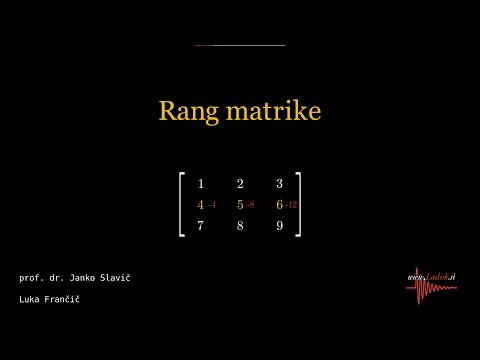

In [3]:
from IPython.display import YouTubeVideo
YouTubeVideo('7YbyijGUbYw', width=800, height=300)

If we perform **elementary operations** on a system of linear equations:

* multiplying any equation by a constant (different from zero),
* changing the order of the equations,
* adding one equation (multiplied by a constant) to another equation,

we do not change the solution of the system and obtain an equivalent system of equations.

Using elementary operations on the rows of the matrix $\mathbf{A}$, we can transform it into the so-called **reduced row echelon form**:

1. if there are zero rows, they are at the bottom of the matrix,
1. the first nonzero element lies to the right of the first nonzero elements of the preceding rows,
1. the first nonzero element in a *row* is called the **pivot** and is equal to 1,
1. the pivot is the only nonzero element in its *column*.


The **rank of a matrix** represents the number of nonzero rows in the reduced row echelon form of the matrix; the number of nonzero rows represents the **number of linearly independent equations and equals the number of pivot elements**. **The rank of a matrix is therefore equal to the number of linearly independent rows of the matrix**. Transposing a matrix does not change its rank, so the rank of a matrix also equals the number of linearly independent *columns* of the matrix.

Example of transforming the matrix $\mathbf{A}$:

In [4]:
import numpy as np #import numpy
A = np.arange(9).reshape((3,3))+1
A

array([[1, 2, 3],
       [4, 5, 6],
       [7, 8, 9]])

Clearly the nonzero element `A[0,0]` has the value 1 and is the pivot element. We multiply the first row `A[0,:]` by $-4$ and add the product to the second row `A[1,:]-4A[0,:]`:

In [5]:
A[1,:] -= A[1,0]*A[0,:]
A

array([[ 1,  2,  3],
       [ 0, -3, -6],
       [ 7,  8,  9]])

We do similarly for the third row:

In [6]:
A[2,:] -= A[2,0]*A[0,:]
A

array([[  1,   2,   3],
       [  0,  -3,  -6],
       [  0,  -6, -12]])

We now divide the second row by `A[1,1]` to obtain the pivot:

In [7]:
A[1,:] = A[1,:]/A[1,1]
A

array([[  1,   2,   3],
       [  0,   1,   2],
       [  0,  -6, -12]])

We subtract the second row from the others, so that in the second column we get zeros everywhere except for the value 1 in the second row:

In [8]:
A[0,:] -= A[0,1]*A[1,:] # subtraction from the first row
A

array([[  1,   0,  -1],
       [  0,   1,   2],
       [  0,  -6, -12]])

In [9]:
A[2,:] -= A[2,1]*A[1,:] # subtraction from the last row
A

array([[ 1,  0, -1],
       [ 0,  1,  2],
       [ 0,  0,  0]])

We have two nonzero rows; the matrix `A` has two pivots and represents two linearly independent equations. The rank of the matrix is 2.

In [10]:
A

array([[ 1,  0, -1],
       [ 0,  1,  2],
       [ 0,  0,  0]])

The rank of a matrix can also be determined using the `numpy` function `numpy.linalg.matrix_rank` ([documentation](https://docs.scipy.org/doc/numpy/reference/generated/numpy.linalg.matrix_rank.html)):

```python
matrix_rank(M, tol=None)
```

where `M` is the matrix whose rank we are looking for, and `tol` is an optional parameter that sets the threshold below which values in the algorithm are treated as equal to zero.

In [11]:
np.linalg.matrix_rank(A)

2

If $r=\textbf{rank}(\mathbf{A})=\textbf{rank}([\mathbf{A}|\mathbf{b}])$, then a solution **exists** (we also say that the system is **consistent**).

A consistent system has:

* exactly one solution when the number of unknowns $n$ equals the rank $r$ (the solution is independent), and
* infinitely many solutions when the rank $r$ is less than the number of unknowns $n$ (the solution depends on $n-r$ parameters).

First we will restrict ourselves to a system of $m=n$ linear equations with $n$ unknowns where $n=r$:

$$\mathbf{A}\,\mathbf{x}=\mathbf{b}.$$

Under the above conditions the coefficient matrix $\mathbf{A}$ is nonsingular ($|\mathbf{A}|\neq 0$) and the system has the solution:

$$\mathbf{x}=\mathbf{A^{-1}}\,\mathbf{b}.$$

Let us look at an example of a system where the **equations are linearly dependent** ($r<n$):

In [12]:
A = np.array([[1 , 2],
              [2, 4]])
b = np.array([1, 2])
Ab = np.column_stack((A,b))
Ab

array([[1, 2, 1],
       [2, 4, 2]])

Using the `numpy` library, let us now look at the rank of the coefficient matrix and of the augmented matrix, as well as the determinant, using `numpy.linalg.det` ([documentation](https://docs.scipy.org/doc/numpy/reference/generated/numpy.linalg.det.html)):

```python
det(a)
```

where `a` is the matrix (or list of matrices) whose determinant we are looking for; the function `det` returns the determinant (or list of determinants).

In [13]:
f'rank(A)={np.linalg.matrix_rank(A)}, rank(Ab)={np.linalg.matrix_rank(Ab)}, \
number of unknowns: {len(A[:,0])}, det(A)={np.linalg.det(A)}'

'rang(A)=1, rang(Ab)=1, število neznank: 2, det(A)=0.0'

Let us also look at an example where **there is no solution at all** (an inconsistent system):

In [14]:
A = np.array([[1 , 2],
              [2, 4]])
b = np.array([1, 1])
Ab = np.column_stack((A,b))
Ab

array([[1, 2, 1],
       [2, 4, 1]])

In [15]:
f'rank(A)={np.linalg.matrix_rank(A)}, rank(Ab)={np.linalg.matrix_rank(Ab)}, \
number of unknowns: {len(A[:,0])}, det(A)={np.linalg.det(A)}'

'rang(A)=1, rang(Ab)=2, število neznank: 2, det(A)=0.0'

### Norm and conditioning of systems of equations

A numerical problem is ill-conditioned if a small change in the data causes a large change in the result. In the case of a *small change in the data* that causes a *small change in the results*, the problem is **well-conditioned**.

A system of equations is usually well-conditioned if the absolute values of the diagonal elements of the coefficient matrix are large compared to the absolute values of the off-diagonal elements.

For a system of linear equations $\mathbf{A}\,\mathbf{x}=\mathbf{b}$ we can compute the **condition number**:

$$\textrm{cond}(\textbf{A})=||\textbf{A}||\,||\textbf{A}^{-1}||.$$

By $||\textbf{A}||$ we denote the **norm** of the matrix.

There are several ways to compute the norm; let us state two:

* the Euclidean norm (also the Frobenius norm):

$$||\textbf{A}||_e=\sqrt{\sum_{i=1}^n\sum_{j=1}^nA_{ij}^2}$$

* the row-sum norm, also called the infinity norm:

$$||\textbf{A}||_{\infty}=\max_{1\le i\le n}\sum_{j=1}^n |A_{ij}|$$

We compute the conditioning with the built-in function `numpy.linalg.cond` ([documentation](https://docs.scipy.org/doc/numpy/reference/generated/numpy.linalg.cond.html)):

```python
cond(x, p=None)
```

which takes two parameters: the matrix `x` and the optional norm type `p` (the default type is `None`; in that case the Euclidean/Frobenius norm is used).

If the condition number is small, then the matrix is well-conditioned, and conversely - for ill-conditioning the condition number increases greatly.

Unfortunately, computing the conditioning of a matrix is numerically relatively demanding.

#### Example of an ill-conditioned matrix

We will look at an ill-conditioned system, where with a tiny change to the coefficient matrix we will cause a large change in the solution.

The coefficient matrix:

In [16]:
A = np.array([[1 , 1],
              [1, 1.00001]])
np.linalg.cond(A)

400002.00000320596

The constant vector:

In [17]:
b = np.array([3, -3])
Ab = np.column_stack((A,b))
Ab

array([[ 1.     ,  1.     ,  3.     ],
       [ 1.     ,  1.00001, -3.     ]])

Let us check the rank and the determinant:

In [18]:
f'rank(A)={np.linalg.matrix_rank(A)}, rank(Ab)={np.linalg.matrix_rank(Ab)}, \
number of unknowns: {len(A[:,0])}, det(A)={np.linalg.det(A)}'

'rang(A)=2, rang(Ab)=2, število neznank: 2, det(A)=1.000000000006551e-05'

We subtract the first equation from the second:

In [19]:
Ab[1,:] -= Ab[0,:]
Ab

array([[ 1.e+00,  1.e+00,  3.e+00],
       [ 0.e+00,  1.e-05, -6.e+00]])

We determine `x1`:

In [20]:
x1 = Ab[1,2]/Ab[1,1]
x1

-599999.9999960692

It remains to determine `x0`:

In [21]:
x0 = (Ab[0,2] - Ab[0,1]*x1)/Ab[0,0]
x0

600002.9999960692

We slightly change the coefficient matrix and repeat the solving:

In [22]:
A = np.array([[1 , 1],
              [1, 1.0001]]) # <= here we changed 1.00001 to 1.0001
np.linalg.cond(A)

40002.000074915224

We repeat the computation:

In [23]:
Ab = np.column_stack((A,b))
f'rank(A)={np.linalg.matrix_rank(A)}, rank(Ab)={np.linalg.matrix_rank(Ab)}, \
number of unknowns: {len(A[:,0])}, det(A)={np.linalg.det(A)}'
Ab[1,:] -= Ab[0,:]
x1_ = Ab[1,2]/Ab[1,1]
x0_ = (Ab[0,2] - Ab[0,1]*x1)/Ab[0,0]

We compare the two solutions:

In [24]:
[x0, x1] # first solution

[600002.9999960692, -599999.9999960692]

In [25]:
[x0_, x1_] # second solution

[600002.9999960692, -60000.00000000661]

We find that a tiny change in one coefficient of the coefficient matrix caused a large change in the result. A small change in the data cannot be avoided, because of how the data is stored in the computer.

### Numerical solution of systems of linear equations


We will look at two approaches to solving systems of linear equations that are in principle different:

A) the **direct approach**: we perform elementary operations on the system of equations, by which we transform the system into one that is easier to solve,

B) the **iterative approach**: we choose an initial approximation and then iteratively improve the approximation.

## Gaussian elimination

Assume that we are solving a system of $n$ equations for $n$ unknowns that has rank $n$. Such a system has a unique solution.

Gaussian elimination is one of the direct methods, since by means of elementary row operations we reduce the system of equations to an upper-triangular system (below the main diagonal in the augmented matrix the values are zero).

First we prepare the augmented coefficient matrix:

$$\begin{bmatrix}
\mathbf{A}|\mathbf{b}
\end{bmatrix}=
\left[\begin{array}{cccc|c}
A_{0,0}&A_{0,1}&\cdots & A_{0,n-1} & b_0\\
A_{1,0}&A_{1,1}&\cdots & A_{1,n-1} & b_1\\
\vdots&\vdots&\ddots & \vdots & \vdots\\
A_{n-1,0}&A_{n-1,1}&\cdots & A_{n-1,n-1} & b_{n-1}\\
\end{array}\right]
$$

We will look at Gaussian elimination through an example:

In [26]:
A = np.array([[ 8., -6, 3],
              [-6, 6,-6],
              [ 3, -6, 6]])
b = np.array([-14, 36, 6])
Ab = np.column_stack((A,b))

In [27]:
Ab

array([[  8.,  -6.,   3., -14.],
       [ -6.,   6.,  -6.,  36.],
       [  3.,  -6.,   6.,   6.]])

Step 0: we multiply the first row by `Ab[1,0]/Ab[0,0]=-6/8` and subtract it from the second:

In [28]:
Ab[1,:] -= Ab[1,0]/Ab[0,0] * Ab[0,:]
Ab

array([[  8.  ,  -6.  ,   3.  , -14.  ],
       [  0.  ,   1.5 ,  -3.75,  25.5 ],
       [  3.  ,  -6.  ,   6.  ,   6.  ]])

Next we multiply the first row by `Ab[2,0]/Ab[0,0]=3/8` and subtract it from the third:

In [29]:
Ab[2,:] -= Ab[2,0]/Ab[0,0] * Ab[0,:]
Ab

array([[  8.   ,  -6.   ,   3.   , -14.   ],
       [  0.   ,   1.5  ,  -3.75 ,  25.5  ],
       [  0.   ,  -3.75 ,   4.875,  11.25 ]])

Step 1: we multiply the second row by `Ab[2,1]/Ab[1,1]=-3.75/1.5` and subtract it from the third:

In [30]:
Ab[2,:] -= Ab[2,1]/Ab[1,1] * Ab[1,:]
Ab

array([[  8.  ,  -6.  ,   3.  , -14.  ],
       [  0.  ,   1.5 ,  -3.75,  25.5 ],
       [  0.  ,   0.  ,  -4.5 ,  75.  ]])

Using the prepared module `modules/gauss_demo.py` we can also animate the procedure:
![Gaussian elimination](./fig/gauss_eliminacija.gif)

We have obtained an upper-triangular matrix and Gaussian elimination is finished. We can compute the solution, that is, determine the vector of unknowns $x$ by **back substitution**.

From the last row of the upper-triangular matrix we compute $x_2$:

In [31]:
Ab

array([[  8.  ,  -6.  ,   3.  , -14.  ],
       [  0.  ,   1.5 ,  -3.75,  25.5 ],
       [  0.  ,   0.  ,  -4.5 ,  75.  ]])

In [32]:
x = np.zeros(3) #prepare an empty list
x[2] = Ab[2,-1]/Ab[2,2]
x

array([  0.        ,   0.        , -16.66666667])

Using the second-to-last row we compute $x_1$:

In [33]:
Ab

array([[  8.  ,  -6.  ,   3.  , -14.  ],
       [  0.  ,   1.5 ,  -3.75,  25.5 ],
       [  0.  ,   0.  ,  -4.5 ,  75.  ]])

In [34]:
x[1] = (Ab[1,-1] - Ab[1,2]*x[2]) / Ab[1,1]
x

array([  0.        , -24.66666667, -16.66666667])

Using the first row we then compute $x_0$:

In [35]:
Ab

array([[  8.  ,  -6.  ,   3.  , -14.  ],
       [  0.  ,   1.5 ,  -3.75,  25.5 ],
       [  0.  ,   0.  ,  -4.5 ,  75.  ]])

In [36]:
x[0] = (Ab[0,3] - Ab[0,1:3]@x[1:]) / Ab[0,0]
x

array([-14.        , -24.66666667, -16.66666667])

Let us check the solution:

In [37]:
A @ x - b

array([-3.55271368e-15,  7.10542736e-15,  7.10542736e-15])

#### Summary of Gaussian elimination

In the module ``tools.py`` we save the functions:

In [38]:
def gaussian_elimination(A, b, show_steps = False):
    Ab = np.column_stack((A, b))
    for p, pivot_row in enumerate(Ab[:-1]):
        for row in Ab[p+1:]:
            if pivot_row[p]:
                row[p:] -= pivot_row[p:]*row[p]/pivot_row[p]
            else:
                raise Exception('Division by 0.')
        if show_steps:
            print('Step: {:g}'.format(p))
            print(Ab)
    return Ab

def gaussian_el_solution(Ub):
    n = len(Ub)
    x = np.zeros(n)
    for p, pivot_row in enumerate(Ub[::-1]):
        x[n-p-1] = (pivot_row[-1] - pivot_row[n-p:-1] @ x[n-p:] ) / (pivot_row[n-p-1])
    return x

The algorithm by which we compute the solution from an upper-triangular system of equations $\mathbf{U}\,\mathbf{x}=\mathbf{b}$ is called **back substitution**; $\mathbf{U}$ is an upper-triangular matrix.

If we were to solve the system $\mathbf{L}\,\mathbf{x}=\mathbf{b}$ where $\mathbf{L}$ is a lower-triangular matrix, we would call this method **forward substitution**.

In [39]:
Ub = gaussian_elimination(A, b, show_steps=False)
Ub

array([[  8.  ,  -6.  ,   3.  , -14.  ],
       [  0.  ,   1.5 ,  -3.75,  25.5 ],
       [  0.  ,   0.  ,  -4.5 ,  75.  ]])

In [40]:
gaussian_el_solution(Ub)

array([-14.        , -24.66666667, -16.66666667])

### Numerical complexity

We assess numerical complexity by the number of mathematical operations required for the computation.
To solve $n$ linear equations with Gaussian elimination, we thus need approximately $n^3/3$ mathematical operations. To determine the unknowns $\mathbf{x}$ we need an additional approximately $n^2$ operations.

In Gaussian elimination we carried out the elimination only for the terms below the diagonal; if we continued the elimination and carried it out also for the terms above the diagonal, we would perform the so-called *Gauss-Jordan* elimination, for which, however, we need an additional approximately $n^3/3$ operations* (which is considered the main drawback of this method).

\* You can find some comments on the topic of the number of numerical operations here: [pinm.ladisk.si](http://pinm.ladisk.si/303/kako-dolo%C4%8Damo-numeri%C4%8Dno-zahtevnost-algoritmov).

### Using the `numpy` library

Solving a system of linear equations with `numpy.linalg.solve` ([documentation](https://docs.scipy.org/doc/numpy/reference/generated/numpy.linalg.solve.html)):

```python
solve(a, b)
```

where `a` is the coefficient matrix (or list of matrices) and `b` is the constant vector (or list of vectors). The function returns the vector (or list of vectors) of solutions.

In [41]:
np.linalg.solve(A, b)

array([-14.        , -24.66666667, -16.66666667])

## Additional

## Example of symbolic solving of a system of linear equations with `sympy`

In [42]:
import sympy as sym
sym.init_printing()

In [43]:
A11, A12, A21, A22 = sym.symbols('A11, A12, A21, A22')
x1, x2 = sym.symbols('x1, x2')
b1, b2 = sym.symbols('b1, b2')
A = sym.Matrix([[A11, A12],
                [A21, A22]])
x = sym.Matrix([[x1],
                [x2]])
b = sym.Matrix([[b1],
                [b2]])

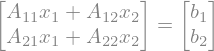

In [44]:
eq = sym.Eq(A*x,b)
eq

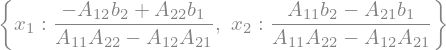

In [45]:
#%%timeit
solution = sym.solve(eq,[x1, x2])
solution

In [46]:
A.det()

---

# Exercise questions

---

## Systems of linear algebraic equations


**Question 1:** Define the system of linear equations written below and solve it using the tools of the ``numpy`` package. Verify the correctness of the solution using matrix multiplication.

$$6x_1 - 2x_2 + x_3 = 18$$
$$2.5x_2 - 0.5x_3 = 5.5$$
$$-x_1 + 4x_3 = 13$$

**Question 2:** The equations of equilibrium of forces and moments for the beam in the figure are written as:

<img src="fig/vaje/nosilec.PNG" style="width:550px">

$$
\begin{align}
\text{direction }x &:\quad A_x - F~\cos(\varphi) = 0\\
\text{direction }y &:\quad A_y + B - F~\sin(\varphi) = 0\\
\text{moment about }A&:\quad Bl - Fa~\sin(\varphi) = 0
\end{align}
$$

Determine the support reactions $[A_x, A_y, B]$ by defining the system of equations in the ``numpy`` environment and solving it with the existing tools.

Data:
* $L = 1$ m
* $a = 0.3$ m
* $F = 105$ N
* $\varphi = \pi /3 $ rad

**Question 3:** You consider a beam very similar to the one in the figure above. You know the angle $\varphi$ and the value $a$, you have measured the support reactions in the vertical direction, but you do not know the length of the beam, the amplitude of the force $F$, or the value of $A_x$.

The equilibrium equations remain the same:

$$
\begin{align}
\text{direction }x &:\quad A_x - F~\cos(\varphi) = 0\\
\text{direction }y &:\quad A_y + B - F~\sin(\varphi) = 0\\
\text{moment about }A&:\quad Bl - Fa~\sin(\varphi) = 0
\end{align}
$$

Compute the values $[A_x, F, L]$.

Data:
* $a = 0.6$ m
* $A_y = 72$ N
* $B = 31$ N
* $\varphi = \pi /4 $ rad

---------

### Uniqueness of the solution


**Question 4**: Write a function that checks whether a system of equations has a unique solution. The function should take as arguments the coefficient matrix $\mathbf{A}$ and the constant vector $\bold{b}$. If the system is solvable it should return ``True``, otherwise it should raise a `ValueError`.

Check the solution of the following systems of equations and comment.

In [ ]:
# Data
A_1 = np.array([[1., 2., 3.],
                [4., 5., 6.],
                [7., 8., 10.]])
b_1 = np.array([6., 15., 25.])


A_2 = np.array([[1., 2., 3.],
                [2., 4., 6.],
                [3., 6., 9.]])
b_2 = np.array([1., 2., 4.])


A_3 = np.array([[1., 2., 3.],
                [2., 4., 6.],
                [3., 6., 9.]])
b_3 = np.array([6., 12., 18.])

----------

### Gaussian elimination

<img src="fig/vaje/Gauss_primer.gif" style="height:400px">


**Question 5:** Write a function ``gauss_eliminacija`` that:
* takes as arguments the matrix $\mathbf{A}$ and the vector $\mathbf{b}$,
* prepares the augmented coefficient matrix $\mathbf{[A|b]}$
* for each pivot row ``i``, $0 \leq i \leq n-1$, computes the coefficient $\lambda$ for all rows below the pivot ($i+1 \leq j \leq n$) ($n$ is the number of rows of $\mathbf{A}$).
$$ \lambda = \frac{a_{ji}}{a_{ii}}$$

*  if the coefficient $a_{ii}$ is different from 0, performs the replacement:

$$E_j \leftarrow E_j - \lambda E_i$$

**Question 6:** Write a function ``gauss_resitev`` that, based on the result of the function ``gauss_eliminacija``, computes the values of the elements of the vector of unknowns $\mathbf{x}$ using back substitution.

   $$x_i = \frac{b_i - \sum_{j=i+1}^{n}a_{ij} x_j}{a_{ii}}$$


**Hint:** A system with an upper-triangular augmented coefficient matrix is solved "from the bottom up". You can reverse the order of the matrix rows with ``A[::-1]``.

---

### Conditioning of systems of linear equations

**Question 7:** Using the tools of the ``numpy`` package, solve the system of equations below. Then increase the element ``A[2,1]`` by $0.1$% and solve the new system once more. Comment on the result, using the value of the determinant, the norm, and the conditioning of the matrix $\mathbf{A}$ to help you.

$$\begin{bmatrix}
1.1 & 22 & -35 \\
-7 & -2.4 & 3.5\\
0.3 & 6.6 & -10.5
\end{bmatrix}
\begin{bmatrix}
x_1 \\ x_2 \\ x_3
\end{bmatrix}
=
\begin{bmatrix}
3 \\ -0.5 \\ 1.5
\end{bmatrix}
$$

In [ ]:
# Data, do not delete!
A = np.array([[1.1, 22, -35],
             [-7.0, -2.4, 3.5],
             [0.3, 6.6, -10.5]])
b = np.array([3, -0.5, 1.5])

**Question 8:** Using the tools of the ``numpy`` package, write your own functions for the Euclidean or infinity norm and for the conditioning measure of a matrix. Compute the conditioning of the coefficient matrix from the problem above.

* Euclidean (Frobenius) norm (square root of the sum of squares of all elements):
    $$||\textbf{A}||_e=\sqrt{\sum_{i=1}^n\sum_{j=1}^nA_{ij}^2}$$
* Infinity norm (maximum of the row sums):
$$||\textbf{A}||_{\infty}=\max_{1\le i\le n}\sum_{j=1}^n |A_{ij}|$$

* Condition number:
$$\textrm{cond}(||\textbf{A}||)=||\textbf{A}||\,||\textbf{A}^{-1}||$$